# 1- Neural Network Design in Pytorch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.nn.functional import conv2d, max_pool2d, cross_entropy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [58]:
plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])


In [59]:
train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

# Cache the transformed MNIST tensors once instead of transforming every epoch.
train_dataset = TensorDataset(
    train_dataset.data.to(device=device, dtype=torch.float32).div_(127.5).sub_(1.0).unsqueeze_(1),
    train_dataset.targets.to(device),
)
test_dataset = TensorDataset(
    test_dataset.data.to(device=device, dtype=torch.float32).div_(127.5).sub_(1.0).unsqueeze_(1),
    test_dataset.targets.to(device),
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [60]:

def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape, device=device) * std
    w.requires_grad = True
    return w

In [61]:
def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.relu(x)


In [62]:
class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])
    
    

In [63]:
# define the neural network
def model(x, w_h, w_h2, w_o):
    h = rectify(x @ w_h)
    h2 = rectify(h @ w_h2)
    pre_softmax = h2 @ w_o
    return pre_softmax

In [64]:

# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

optimizer = RMSprop(params=[w_h, w_h2, w_o], lr=1e-3, alpha=0.9)


In [65]:
n_epochs = 100

train_loss = []
test_loss = []

In [20]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")

2.9.1+cu128
True
NVIDIA GeForce RTX 3060 Laptop GPU


In [21]:
# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = model(x, w_h, w_h2, w_o)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(loss.detach())

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(torch.stack(train_loss_this_epoch).mean().item())

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(loss)

        test_loss.append(torch.stack(test_loss_this_epoch).mean().item())

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")



Epoch: 0
Mean Train Loss: 3.80e-01
Mean Test Loss:  1.48e-01
Epoch: 10
Mean Train Loss: 7.49e-02
Mean Test Loss:  1.50e-01
Epoch: 20
Mean Train Loss: 6.06e-02
Mean Test Loss:  2.84e-01
Epoch: 30
Mean Train Loss: 5.27e-02
Mean Test Loss:  2.57e-01
Epoch: 40
Mean Train Loss: 3.72e-02
Mean Test Loss:  4.66e-01
Epoch: 50
Mean Train Loss: 3.71e-02
Mean Test Loss:  6.34e-01
Epoch: 60
Mean Train Loss: 3.15e-02
Mean Test Loss:  5.44e-01
Epoch: 70
Mean Train Loss: 3.06e-02
Mean Test Loss:  6.48e-01
Epoch: 80
Mean Train Loss: 2.55e-02
Mean Test Loss:  5.35e-01
Epoch: 90
Mean Train Loss: 1.85e-02
Mean Test Loss:  6.99e-01
Epoch: 100
Mean Train Loss: 2.19e-02
Mean Test Loss:  7.60e-01


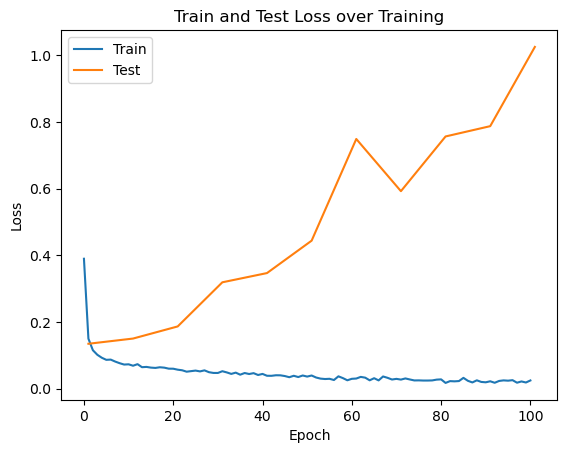

In [63]:
plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

#### from the test_loss and train_lost figure, it is obvious that the model is overfitting. The train loss is decreasing, but the test loss is increasing after a certain point. This indicates that the model is learning the training data too well and is not generalizing to unseen data.

> we intend to reduce this overfitting and solve the issue by using dropout technique

# 2- Dropout

In [13]:
def dropout(X, p_drop=0.5):
    if p_drop == 0:
        return X
    
    # ensuring p is between 0 and 1
    p = min(max(p_drop, 0.0), 1.0)

    # generating binary mask: 1 keep, 0 drop
    # using bernoulli destro with probability 1-p 
    mask = (torch.rand_like(X) > p).float()


    output = X * mask / (1.0 - p)

    return output

In [65]:
# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch
        
        # our model requires flattened input
        x = x.reshape(batch_size, 784)

        # apply dropout to first layer
        x = dropout(x, p_drop=0.5)
        # we know this would not work 

        # feed input through model
        noise_py_x = model(x, w_h, w_h2, w_o)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()



    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)

                x = dropout(x, p_drop=0.5)

                
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")



Epoch: 0
Mean Train Loss: 6.00e-01
Mean Test Loss:  5.10e-01


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (101,) and (202,)

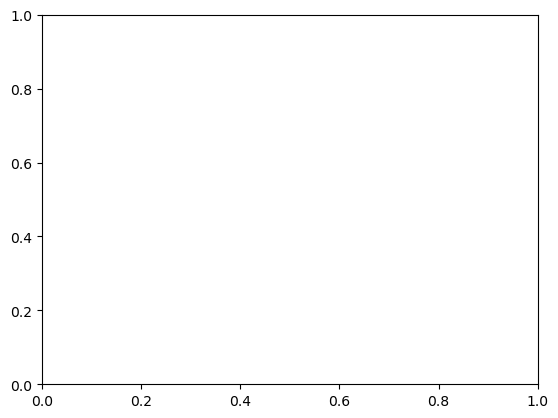

In [39]:
plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

As it is visible I wrote dropout function and used it in my training loop but used it on x (just first input) so it will effect first layer and the rest would cause again overfitting. 

> I will solve this in the leading cell by converting model function that was written to dropout

In [66]:
def dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden):
    
    # apply input dropout
    if p_drop_input > 0:
        mask = (torch.rand_like(X) > p_drop_input).float()
        X = X * mask / (1.0 - p_drop_input)

    # first hidden layer
    h = rectify(X @ w_h)
    if p_drop_hidden > 0:
        mask = (torch.rand_like(h) > p_drop_hidden).float()
        h = h * mask / (1.0 - p_drop_hidden)

    # second hidden layer
    h2 = rectify(h @ w_h2)
    if p_drop_hidden > 0:
        mask = (torch.rand_like(h2) > p_drop_hidden).float()
        h2 = h2 * mask / (1.0 - p_drop_hidden)

    # output

    pre_softmax = h2 @ w_o
    return pre_softmax


In [67]:
n_epochs = 100

train_loss_dropout = []
test_loss_dropout = []

for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        x = x.reshape(batch_size, 784)
        
        #we use 
        noise_py_x = dropout_model(x, w_h, w_h2, w_o, 
                                   p_drop_input=0.1, p_drop_hidden=0.3)
        
        optimizer.zero_grad()

        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        loss.backward()
        optimizer.step()

        

    train_loss_dropout.append(np.mean(train_loss_this_epoch))

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss_dropout[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
            
                # again apply dropout here
                noise_py_x = dropout_model(x, w_h, w_h2, w_o, 
                                           p_drop_input=0.0, p_drop_hidden=0.0)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

            

        test_loss_dropout.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss_dropout[-1]:.2e}")


%time

Epoch: 0
Mean Train Loss: 4.99e-01
Mean Test Loss:  1.91e-01
Epoch: 10
Mean Train Loss: 2.06e-01
Mean Test Loss:  1.10e-01
Epoch: 20
Mean Train Loss: 1.89e-01
Mean Test Loss:  1.29e-01
Epoch: 30
Mean Train Loss: 1.84e-01
Mean Test Loss:  1.24e-01
Epoch: 40
Mean Train Loss: 1.96e-01
Mean Test Loss:  1.47e-01
Epoch: 50
Mean Train Loss: 1.99e-01
Mean Test Loss:  1.83e-01
Epoch: 60
Mean Train Loss: 1.91e-01
Mean Test Loss:  1.76e-01
Epoch: 70
Mean Train Loss: 2.03e-01
Mean Test Loss:  1.53e-01
Epoch: 80
Mean Train Loss: 2.15e-01
Mean Test Loss:  1.82e-01
Epoch: 90
Mean Train Loss: 2.10e-01
Mean Test Loss:  1.93e-01
Epoch: 100
Mean Train Loss: 2.16e-01
Mean Test Loss:  2.13e-01
CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 4.77 μs


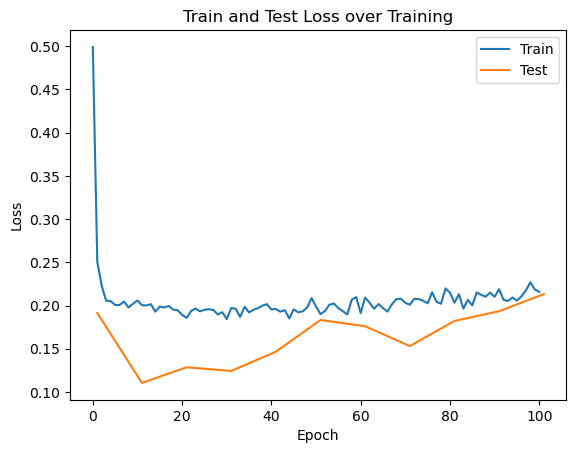

In [ ]:
plt.plot(np.arange(n_epochs + 1), train_loss_dropout, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss_dropout, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

### why we use dropout:

fully connected layer -> large number of neurons -> co-adaption 


co-adaption -> when multiple neurongs in a layer extract the same or very similar features


When the connection weights for 2 different neurons are nearly identical
	
#### problems:
Wastage of machine's resources when computing the same output.

if more neurons are extracting the same features, it adds more significance to those features for our model. 
		
		
This will lead to overfitting ->> if the duplicate extracted features are specific to only the training set.
		
	
#### mitigation: 
we minimize co-adaption by using dropout
	
	
#### functionality:
we randomly shutdown some fractions of a layer's neurons at each training step 


-> zero out the neuron value.
		
#### dropout rate:
The fraction of neurons to be zeroed out (rd)


the remaining neurons have their values multiplied by 1/1-rd


then the overall sums of neurons values will be the same
	
	
#### benefits:
By using dropout, in every iteration, we work on a smaller neural network 


-> approaches regularization
		


Dropout helps in shrinking the squared norm of the weights


-> leads to reduction of overfitting

# 2- Parametric Relu

In [50]:
# initialize weights

w_h = init_weights((784, 625))
w_h2 = init_weights((625, 625))
w_o = init_weights((625, 10))

# Learnable parameters for PReLU (initialized to 0.25)
a1 = torch.tensor(0.25, device=device, requires_grad=True)
a2 = torch.tensor(0.25, device=device, requires_grad=True)

# I am playing with learning rate and alpha so it may defere from the previous one (no worries there)
# here I added a1, a2 to params 
optimizer = RMSprop(params=[w_h, w_h2, w_o, a1, a2], lr=1e-4, alpha=0.5)


In [51]:
# define PReLU function
def PRelu(X, a):
    """
        x: input tensor of shape(batch_size, features)
        a: learnable parameter or scalar
    """
    return torch.where(X > 0, X, a*X)

In [52]:
# layers with PRelu model
def PRelu_model(x, w_h, w_h2, w_o, a1, a2):
    h = PRelu(x @ w_h, a1)
    h2 = PRelu(h @ w_h2, a2)
    pre_softmax = h2 @ w_o
    return pre_softmax

##### First we try:
>   without dropout training

In [25]:
# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = PRelu_model(x, w_h, w_h2, w_o, a1, a2)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(loss.detach())

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(torch.stack(train_loss_this_epoch).mean().item())

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = PRelu_model(x, w_h, w_h2, w_o, a1, a2)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(loss)

        test_loss.append(torch.stack(test_loss_this_epoch).mean().item())

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")



Epoch: 0
Mean Train Loss: 4.14e-01
Mean Test Loss:  2.50e-01
Epoch: 10
Mean Train Loss: 4.29e-02
Mean Test Loss:  8.13e-02
Epoch: 20
Mean Train Loss: 1.23e-02
Mean Test Loss:  7.37e-02
Epoch: 30
Mean Train Loss: 4.43e-03
Mean Test Loss:  8.59e-02
Epoch: 40
Mean Train Loss: 1.81e-03
Mean Test Loss:  9.82e-02
Epoch: 50
Mean Train Loss: 8.33e-04
Mean Test Loss:  1.18e-01
Epoch: 60
Mean Train Loss: 4.12e-04
Mean Test Loss:  1.37e-01
Epoch: 70
Mean Train Loss: 4.91e-04
Mean Test Loss:  1.40e-01
Epoch: 80
Mean Train Loss: 5.27e-05
Mean Test Loss:  1.64e-01
Epoch: 90
Mean Train Loss: 1.27e-04
Mean Test Loss:  1.65e-01
Epoch: 100
Mean Train Loss: 1.71e-05
Mean Test Loss:  1.80e-01


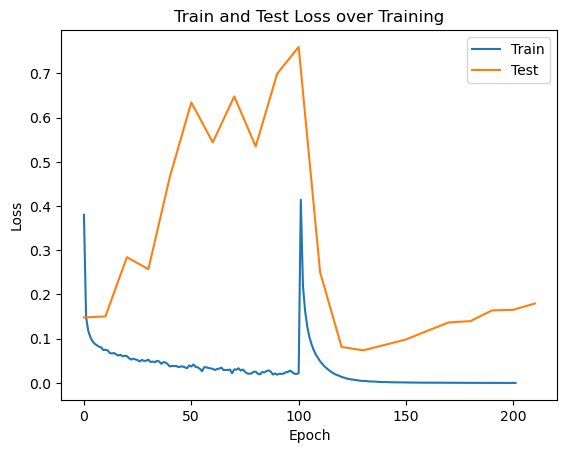

In [28]:
plt.plot(np.arange(len(train_loss)), train_loss, label="Train")
plt.plot(np.arange(len(test_loss)) * 10, test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

#### as you can see its not really approvable
because we used PRelu without using dropout


In [53]:
# dropout_model with PRelu
def dropout_model(X, w_h, w_h2, w_o, a1, a2, p_drop_input, p_drop_hidden):
    # Input dropout
    if p_drop_input > 0:
        mask = (torch.rand_like(X) > p_drop_input).float()
        X = X * mask / (1.0 - p_drop_input)
    
    # First hidden layer with PReLU
    h = X @ w_h
    h = PRelu(h, a1)          # instead of rectify
    if p_drop_hidden > 0:
        mask = (torch.rand_like(h) > p_drop_hidden).float()
        h = h * mask / (1.0 - p_drop_hidden)
    
    # Second hidden layer with PReLU
    h2 = h @ w_h2
    h2 = PRelu(h2, a2)        # instead of rectify
    if p_drop_hidden > 0:
        mask = (torch.rand_like(h2) > p_drop_hidden).float()
        h2 = h2 * mask / (1.0 - p_drop_hidden)
    
    # Output layer (no activation)
    pre_softmax = h2 @ w_o
    return pre_softmax

In [54]:
n_epochs = 100

train_loss_2 = []
test_loss_2 = []

for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        x = x.reshape(batch_size, 784)
        
        #we use 
        noise_py_x = dropout_model(x, w_h, w_h2, w_o, a1, a2, 
                                   p_drop_input=0.1, p_drop_hidden=0.3)
        
        optimizer.zero_grad()

        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        loss.backward()
        optimizer.step()

        

    train_loss_2.append(np.mean(train_loss_this_epoch))

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss_2[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
            
                # again apply dropout here
                noise_py_x = dropout_model(x, w_h, w_h2, w_o, a1, a2, 
                                           p_drop_input=0.0, p_drop_hidden=0.0)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

            

        test_loss_2.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss_2[-1]:.2e}")


%time

Epoch: 0
Mean Train Loss: 6.88e-01
Mean Test Loss:  2.82e-01
Epoch: 10
Mean Train Loss: 1.49e-01
Mean Test Loss:  9.72e-02
Epoch: 20
Mean Train Loss: 1.05e-01
Mean Test Loss:  7.20e-02
Epoch: 30
Mean Train Loss: 8.70e-02
Mean Test Loss:  6.63e-02
Epoch: 40
Mean Train Loss: 7.50e-02
Mean Test Loss:  6.84e-02
Epoch: 50
Mean Train Loss: 6.62e-02
Mean Test Loss:  6.36e-02
Epoch: 60
Mean Train Loss: 6.42e-02
Mean Test Loss:  6.36e-02
Epoch: 70
Mean Train Loss: 5.75e-02
Mean Test Loss:  6.98e-02
Epoch: 80
Mean Train Loss: 5.53e-02
Mean Test Loss:  6.82e-02
Epoch: 90
Mean Train Loss: 4.91e-02
Mean Test Loss:  6.65e-02
Epoch: 100
Mean Train Loss: 4.79e-02
Mean Test Loss:  6.48e-02
CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 5.48 μs


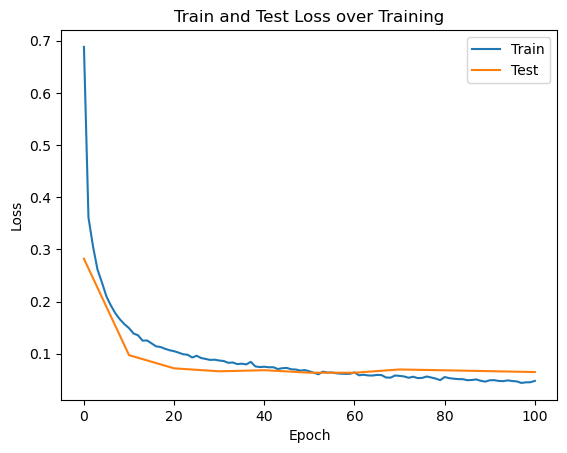

In [55]:
plt.plot(np.arange(len(train_loss_2)), train_loss_2, label="Train")
plt.plot(np.arange(len(test_loss_2)) * 10, test_loss_2, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

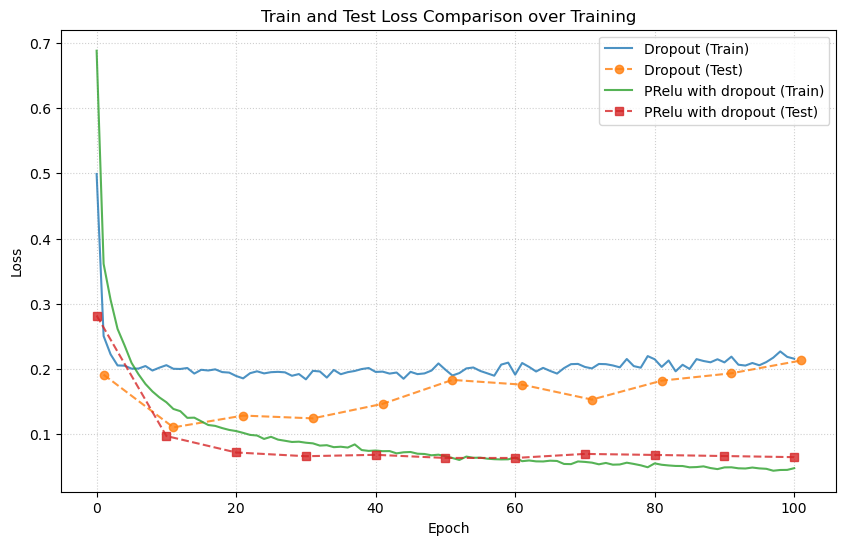

In [70]:
plt.figure(figsize=(10, 6))

# Model 1: Dropout (with PReLU) – same as your first snippet
plt.plot(np.arange(n_epochs + 1), train_loss_dropout, 
         label='Dropout (Train)', linestyle='-', alpha=0.8)
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss_dropout, 
         label='Dropout (Test)', linestyle='--', marker='o', alpha=0.8)

# Model 2: Second model (e.g., no dropout, or standard ReLU)
plt.plot(np.arange(len(train_loss_2)), train_loss_2, 
         label='PRelu with dropout (Train)', linestyle='-', alpha=0.8)
plt.plot(np.arange(len(test_loss_2)) * 10, test_loss_2, 
         label='PRelu with dropout (Test)', linestyle='--', marker='s', alpha=0.8)

plt.title("Train and Test Loss Comparison over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 4- Convolutional Layers

In [75]:
def dropout(X, p_drop=0.5):
    if p_drop == 0:
        return X
    
    # ensuring p is between 0 and 1
    p = min(max(p_drop, 0.0), 1.0)

    # generating binary mask: 1 keep, 0 drop
    # using bernoulli destro with probability 1-p 
    mask = (torch.rand_like(X) > p).float()


    output = X * mask / (1.0 - p)

    return output

In [79]:
def cnn_model(x, w_conv1, w_conv2, w_conv3, w_h2, w_o,
              p_drop_conv=0.25):
    """
    x: input tensor of shape (batch_size, 1, 28, 28)
    """
    x = rectify(conv2d(x, w_conv1, stride=1, padding=0))   # -> 32x24x24
    x = max_pool2d(x, kernel_size=2, stride=2)             # -> 32x12x12
    x = dropout(x, p_drop_conv)
    
    x = rectify(conv2d(x, w_conv2, stride=1, padding=0))   # -> 64x8x8
    x = max_pool2d(x, kernel_size=2, stride=2)             # -> 64x4x4
    x = dropout(x, p_drop_conv)
    
    x = rectify(conv2d(x, w_conv3, stride=1, padding=0))   # -> 128x2x2
    x = max_pool2d(x, kernel_size=2, stride=2)             # -> 128x1x1
    x = dropout(x, p_drop_conv)
    
    x = x.reshape(x.size(0), -1)                           # -> (batch, 128)
    
    x = rectify(x @ w_h2)                                  # -> (batch, 625)
    pre_softmax = x @ w_o                                  # -> (batch, 10)
    return pre_softmax

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convolutional weights: (out_channels, in_channels, kernel_h, kernel_w)
w_conv1 = init_weights((32, 1, 5, 5))
w_conv2 = init_weights((64, 32, 5, 5))
w_conv3 = init_weights((128, 64, 3, 3))

# Fully connected weights
w_h2 = init_weights((128, 625))
w_o = init_weights((625, 10))

# Move all to device
params = [w_conv1, w_conv2, w_conv3, w_h2, w_o]
for p in params:
    p.data = p.data.to(device)
    p.requires_grad = True

optimizer = RMSprop(params, lr=0.001)  

In [83]:
n_epochs = 50  
train_loss_cnn = []
test_loss_cnn = []

for epoch in range(n_epochs + 1):
    train_loss_this = []
    for x, y in train_dataloader:
        x = x.to(device)          # already shape (batch, 1, 28, 28)
        y = y.to(device)
        
        logits = cnn_model(x, w_conv1, w_conv2, w_conv3, w_h2, w_o,
                           p_drop_conv=0.25)
        loss = cross_entropy(logits, y, reduction="mean")
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss_this.append(loss.item())
    
    train_loss_cnn.append(np.mean(train_loss_this))
    
    if epoch % 10 == 0:
        with torch.no_grad():
            test_loss_this = []
            for x, y in test_dataloader:
                x = x.to(device)
                y = y.to(device)
                logits = cnn_model(x, w_conv1, w_conv2, w_conv3, w_h2, w_o,
                                   p_drop_conv=0.25)  # no dropout
                loss = cross_entropy(logits, y, reduction="mean")
                test_loss_this.append(loss.item())
            test_loss_cnn.append(np.mean(test_loss_this))
        
        print(f"Epoch {epoch:3d} | Train loss: {train_loss_cnn[-1]:.3f} | Test loss: {test_loss_cnn[-1]:.3f}")

Epoch   0 | Train loss: 0.307 | Test loss: 0.225
Epoch  10 | Train loss: 0.223 | Test loss: 0.203
Epoch  20 | Train loss: 0.289 | Test loss: 0.240
Epoch  30 | Train loss: 0.340 | Test loss: 0.270
Epoch  40 | Train loss: 0.376 | Test loss: 0.372
Epoch  50 | Train loss: 0.393 | Test loss: 0.409


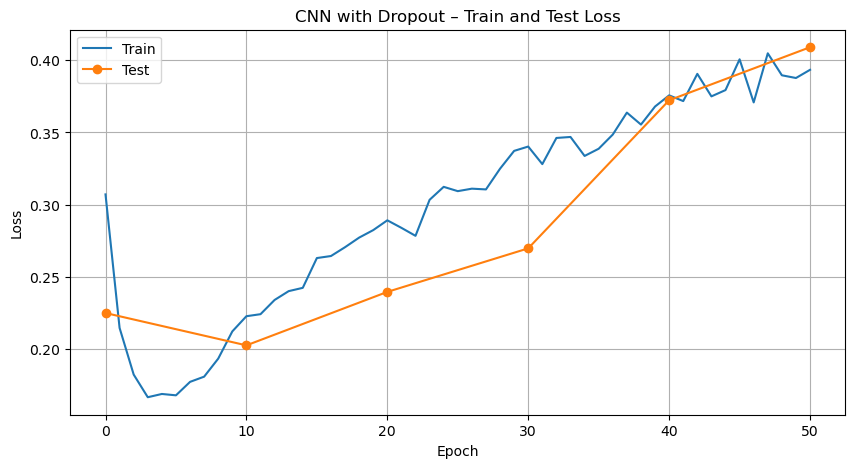

In [84]:
plt.figure(figsize=(10,5))
plt.plot(np.arange(n_epochs+1), train_loss_cnn, label='Train')
test_epochs = list(range(0, n_epochs+1, 10))
plt.plot(test_epochs, test_loss_cnn, 'o-', label='Test')
plt.title("CNN with Dropout – Train and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Network architecture

Input: 1 x 28 x 28

-> Conv1: 32 filters, 5 x 5 -> 32 x 24 x 24 -> Pool -> 32 x 12 x 12

-> Conv2: 64 filters, 5 x 5 -> 64 x 8 x 8 -> Pool -> 64 x 4 x 4

-> Conv3: 128 filters, 3 x 3 -> 128 x 2 x 2 -> Pool -> 128 x 1 x 1

-> Flatten: 128 -> Hidden: 625 -> Output: 10

The final convolutional output contains 128 x 1 x 1 = 128 pixels.

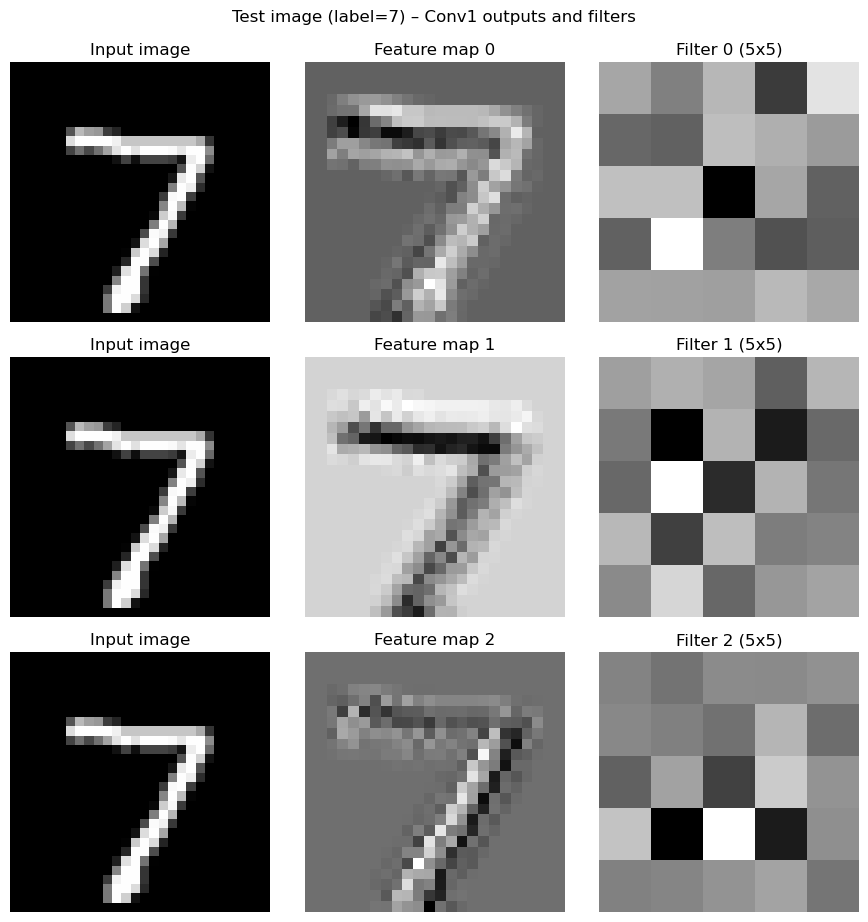

In [90]:
# Get one test image
test_iter = iter(test_dataloader)
img, label = next(test_iter)
img = img[0:1].to(device)      # shape (1,1,28,28)
label = label[0].item()

# Forward pass up to first conv output (before ReLU/pool)
with torch.no_grad():
    conv1_out = conv2d(img, w_conv1, stride=1, padding=0)   # (1,32,24,24)

# Pick 3 filters (indices 0,1,2) and their output feature maps
# detach() removes gradient tracking, then move to CPU
filters = w_conv1[0:3].detach().cpu()          # shape (3,1,5,5)
feature_maps = conv1_out[0, 0:3].detach().cpu() # shape (3,24,24)
img_disp = img[0,0].detach().cpu()             # shape (28,28)

# Plotting
fig, axes = plt.subplots(3, 3, figsize=(9,9))

# First column: original image (same for all rows)
for i in range(3):
    axes[i,0].imshow(img_disp, cmap='gray')
    axes[i,0].set_title("Input image")
    axes[i,0].axis('off')

# Second column: feature maps
for i in range(3):
    axes[i,1].imshow(feature_maps[i], cmap='gray')
    axes[i,1].set_title(f"Feature map {i}")
    axes[i,1].axis('off')

# Third column: filter weights (squeeze to remove channel dim)
for i in range(3):
    axes[i,2].imshow(filters[i,0], cmap='gray')
    axes[i,2].set_title(f"Filter {i} (5x5)")
    axes[i,2].axis('off')

plt.tight_layout()
plt.suptitle(f"Test image (label={label}) – Conv1 outputs and filters", y=1.02)
plt.show()

In [97]:
# Deep CNN with 4 convolutional layers

def dropout(x, p=0.5, training=True):
    """
    Dropout layer.
    x: input tensor
    p: dropout probability (fraction of elements set to zero)
    training: if False, returns x unchanged (evaluation mode)
    """
    if not training or p == 0:
        return x
    p = min(max(p, 0.0), 1.0)
    mask = (torch.rand_like(x) > p).float()
    return x * mask / (1.0 - p)

def init_deep_cnn_params(device):
    """Initialize all parameters for the deep CNN."""
    w_conv1 = init_weights((32, 1, 5, 5)).to(device)
    w_conv2 = init_weights((64, 32, 5, 5)).to(device)
    w_conv3 = init_weights((128, 64, 3, 3)).to(device)
    w_conv4 = init_weights((128, 128, 2, 2)).to(device)
    w_h2   = init_weights((128, 625)).to(device)
    w_o    = init_weights((625, 10)).to(device)
    return [w_conv1, w_conv2, w_conv3, w_conv4, w_h2, w_o]

def deep_cnn_model(x, w_conv1, w_conv2, w_conv3, w_conv4, w_h2, w_o,
                   p_drop_conv=0.1, p_drop_hidden=0.1, training=True):
    """
    x: input tensor (batch, 1, 28, 28)
    """
    # Block 1
    x = rectify(conv2d(x, w_conv1, stride=1, padding=0))
    x = max_pool2d(x, kernel_size=2, stride=2)
    x = dropout(x, p=p_drop_conv, training=training)
    
    # Block 2
    x = rectify(conv2d(x, w_conv2, stride=1, padding=0))
    x = max_pool2d(x, kernel_size=2, stride=2)
    x = dropout(x, p=p_drop_conv, training=training)
    
    # Block 3 (with padding=1 to keep spatial size before pooling)
    x = rectify(conv2d(x, w_conv3, stride=1, padding=1))
    x = max_pool2d(x, kernel_size=2, stride=2)
    x = dropout(x, p=p_drop_conv, training=training)
    
    # Block 4 (no pooling, kernel 2x2 reduces from 2x2 to 1x1)
    x = rectify(conv2d(x, w_conv4, stride=1, padding=0))
    x = dropout(x, p=p_drop_conv, training=training)
    
    # Flatten
    x = x.reshape(x.size(0), -1)   # -> (batch, 128)
    
    # Fully connected
    x = rectify(x @ w_h2)
    x = dropout(x, p=p_drop_hidden, training=training)
    logits = x @ w_o
    return logits

In [98]:
# Initialise parameters on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
deep_cnn_params = init_deep_cnn_params(device)

optimizer = RMSprop(deep_cnn_params, lr=0.001)

n_epochs = 100
train_loss_deep = []
test_loss_deep = []

for epoch in range(n_epochs + 1):
    # ----- Training -----
    train_loss_this = []
    for x, y in train_dataloader:
        x = x.to(device)        # already shape (batch, 1, 28, 28)
        y = y.to(device)
        
        logits = deep_cnn_model(x, *deep_cnn_params,
                                p_drop_conv=0.1, p_drop_hidden=0.1)      # enables dropout
        loss = cross_entropy(logits, y, reduction="mean")
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_this.append(loss.item())
    
    train_loss_deep.append(np.mean(train_loss_this))
    
    # ----- Evaluation every 10 epochs -----
    if epoch % 10 == 0:
        test_loss_this = []
        with torch.no_grad():
            for x, y in test_dataloader:
                x = x.to(device)
                y = y.to(device)
                logits = deep_cnn_model(x, *deep_cnn_params,
                                        p_drop_conv=0.0, p_drop_hidden=0.0,
                                        training=False)   # disables dropout
                loss = cross_entropy(logits, y, reduction="mean")
                test_loss_this.append(loss.item())
        test_loss_deep.append(np.mean(test_loss_this))
        
        print(f"Epoch: {epoch:3d} | Train Loss: {train_loss_deep[-1]:.2e} | Test Loss: {test_loss_deep[-1]:.2e}")

# Find best test loss
best_test = min(test_loss_deep) if test_loss_deep else float('inf')
best_epoch = test_loss_deep.index(best_test) * 10
print(f"\nBest Test Loss: {best_test:.2e} at epoch {best_epoch}")

Epoch:   0 | Train Loss: 1.61e+00 | Test Loss: 1.35e-01
Epoch:  10 | Train Loss: 3.01e-01 | Test Loss: 1.27e-01
Epoch:  20 | Train Loss: 4.34e-01 | Test Loss: 1.18e-01
Epoch:  30 | Train Loss: 5.97e-01 | Test Loss: 2.95e-01
Epoch:  40 | Train Loss: 8.87e-01 | Test Loss: 4.31e-01
Epoch:  50 | Train Loss: 1.06e+00 | Test Loss: 6.46e-01
Epoch:  60 | Train Loss: 1.33e+00 | Test Loss: 3.38e-01
Epoch:  70 | Train Loss: 1.48e+00 | Test Loss: 7.41e-01
Epoch:  80 | Train Loss: 2.00e+00 | Test Loss: 1.27e+00
Epoch:  90 | Train Loss: 2.59e+00 | Test Loss: 9.62e-01
Epoch: 100 | Train Loss: 2.92e+00 | Test Loss: 2.13e+00

Best Test Loss: 1.18e-01 at epoch 20


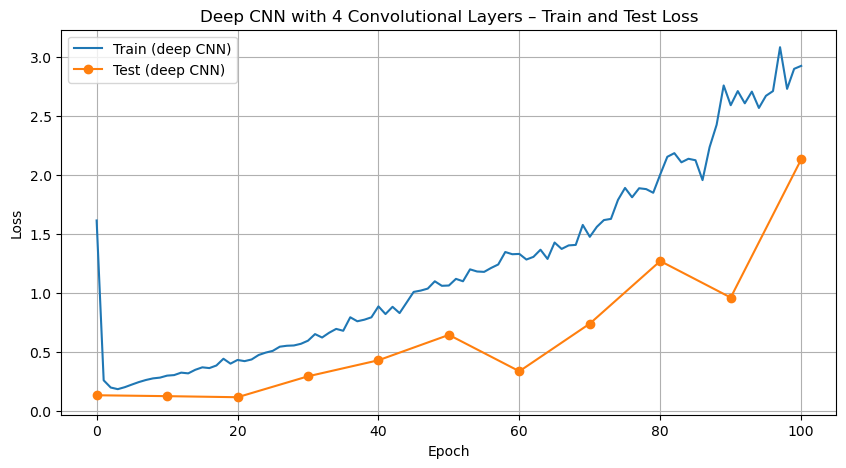

In [99]:
plt.figure(figsize=(10,5))
plt.plot(np.arange(n_epochs+1), train_loss_deep, label='Train (deep CNN)')
test_epochs = list(range(0, n_epochs+1, 10))
plt.plot(test_epochs, test_loss_deep, 'o-', label='Test (deep CNN)')
plt.title("Deep CNN with 4 Convolutional Layers – Train and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

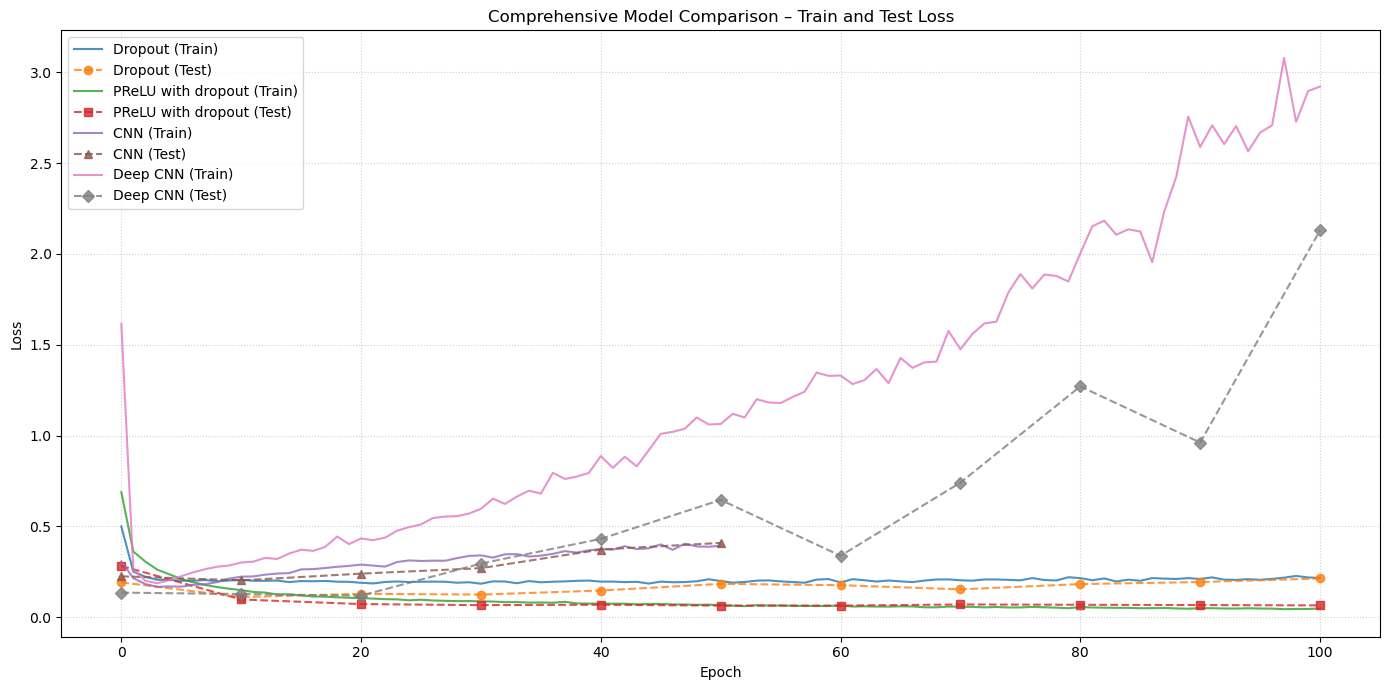

In [101]:
plt.figure(figsize=(14, 7))

# Model 1: Dropout (with PReLU)
plt.plot(np.arange(len(train_loss_dropout)), train_loss_dropout, 
         label='Dropout (Train)', linestyle='-', alpha=0.8)
plt.plot(np.arange(len(test_loss_dropout)) * 10, test_loss_dropout, 
         label='Dropout (Test)', linestyle='--', marker='o', alpha=0.8)

# Model 2: PReLU with dropout
plt.plot(np.arange(len(train_loss_2)), train_loss_2, 
         label='PReLU with dropout (Train)', linestyle='-', alpha=0.8)
plt.plot(np.arange(len(test_loss_2)) * 10, test_loss_2, 
         label='PReLU with dropout (Test)', linestyle='--', marker='s', alpha=0.8)

# Model 3: CNN with dropout
plt.plot(np.arange(len(train_loss_cnn)), train_loss_cnn, 
         label='CNN (Train)', linestyle='-', alpha=0.8)
plt.plot(np.arange(len(test_loss_cnn)) * 10, test_loss_cnn, 
         label='CNN (Test)', linestyle='--', marker='^', alpha=0.8)

# Model 4: Deep CNN
plt.plot(np.arange(len(train_loss_deep)), train_loss_deep, 
         label='Deep CNN (Train)', linestyle='-', alpha=0.8)
plt.plot(np.arange(len(test_loss_deep)) * 10, test_loss_deep, 
         label='Deep CNN (Test)', linestyle='--', marker='D', alpha=0.8)

plt.title("Comprehensive Model Comparison – Train and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [102]:
import pandas as pd

# Create comparison table
comparison_data = {
    'Model': ['Dropout', 'PReLU + Dropout', 'CNN', 'Deep CNN'],
    'Train Loss (Initial)': [train_loss_dropout[0], train_loss_2[0], train_loss_cnn[0], train_loss_deep[0]],
    'Train Loss (Final)': [train_loss_dropout[-1], train_loss_2[-1], train_loss_cnn[-1], train_loss_deep[-1]],
    'Train Loss (Best)': [min(train_loss_dropout), min(train_loss_2), min(train_loss_cnn), min(train_loss_deep)],
    'Test Loss (Initial)': [test_loss_dropout[0], test_loss_2[0], test_loss_cnn[0], test_loss_deep[0]],
    'Test Loss (Final)': [test_loss_dropout[-1], test_loss_2[-1], test_loss_cnn[-1], test_loss_deep[-1]],
    'Test Loss (Best)': [min(test_loss_dropout), min(test_loss_2), min(test_loss_cnn), min(test_loss_deep)],
}

df_comparison = pd.DataFrame(comparison_data)

print("=" * 120)
print("Model Loss Comparison Table")
print("=" * 120)
print(df_comparison.to_string(index=False))
print("=" * 120)

# Display as formatted table in notebook
display(df_comparison.round(4))

Model Loss Comparison Table
          Model  Train Loss (Initial)  Train Loss (Final)  Train Loss (Best)  Test Loss (Initial)  Test Loss (Final)  Test Loss (Best)
        Dropout              0.499114            0.215761           0.184157             0.191350           0.213079          0.110479
PReLU + Dropout              0.688103            0.047904           0.044012             0.282046           0.064834          0.063580
            CNN              0.307143            0.393331           0.166816             0.225067           0.408958          0.202698
       Deep CNN              1.613970            2.922054           0.186616             0.134993           2.130556          0.118355


,Model,Train Loss (Initial),Train Loss (Final),Train Loss (Best),Test Loss (Initial),Test Loss (Final),Test Loss (Best)
0,Dropout,0.4991,0.2158,0.1842,0.1913,0.2131,0.1105
1,PReLU + Dropout,0.6881,0.0479,0.0440,0.2820,0.0648,0.0636
2,CNN,0.3071,0.3933,0.1668,0.2251,0.4090,0.2027
3,Deep CNN,1.6140,2.9221,0.1866,0.1350,2.1306,0.1184
